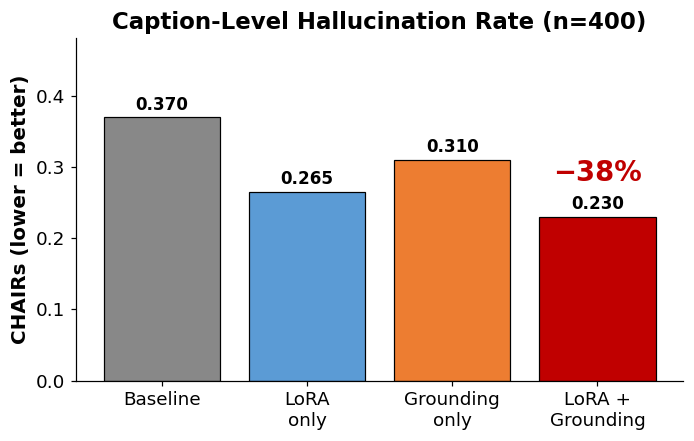

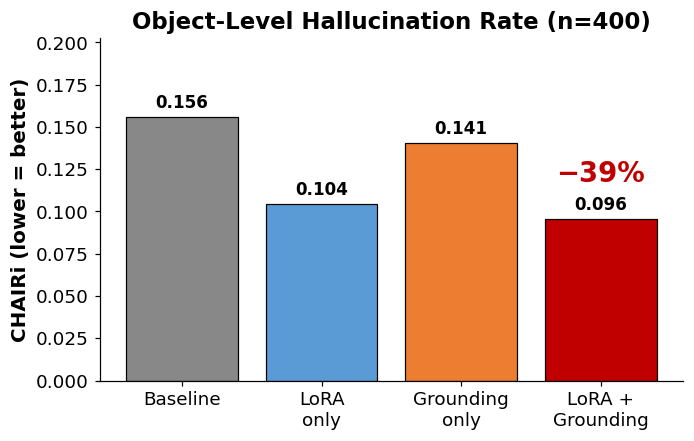

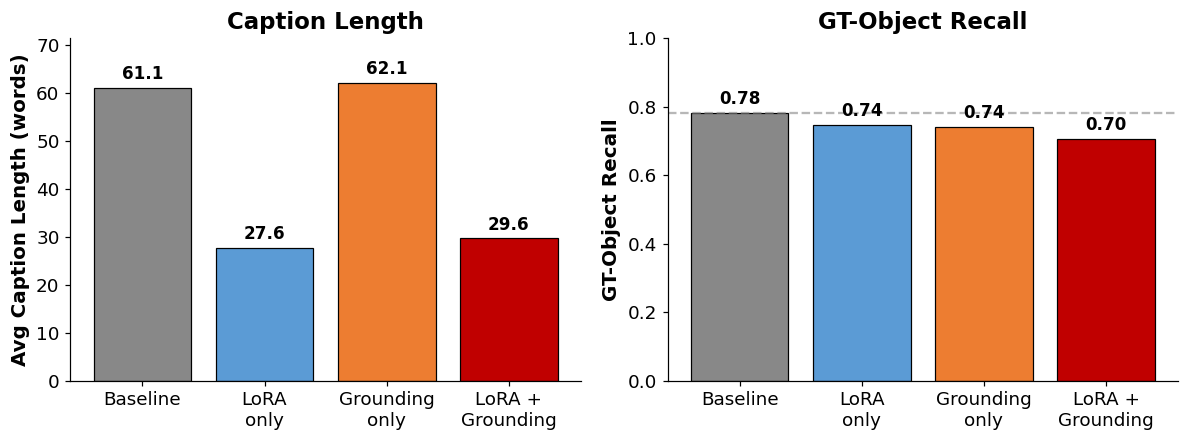

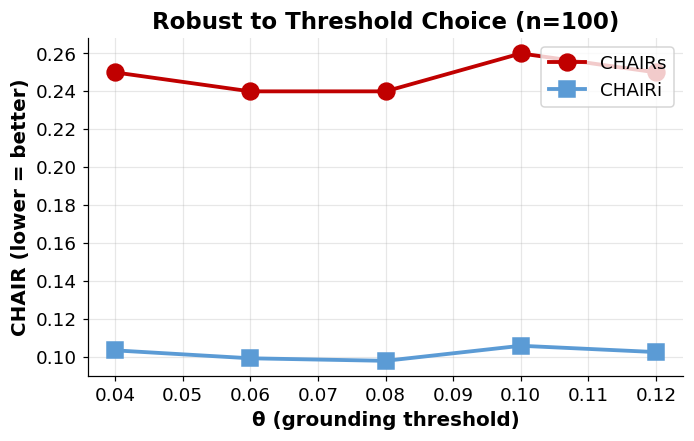

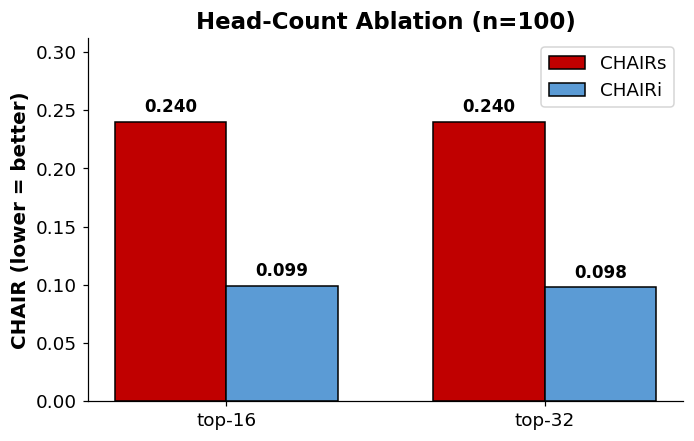

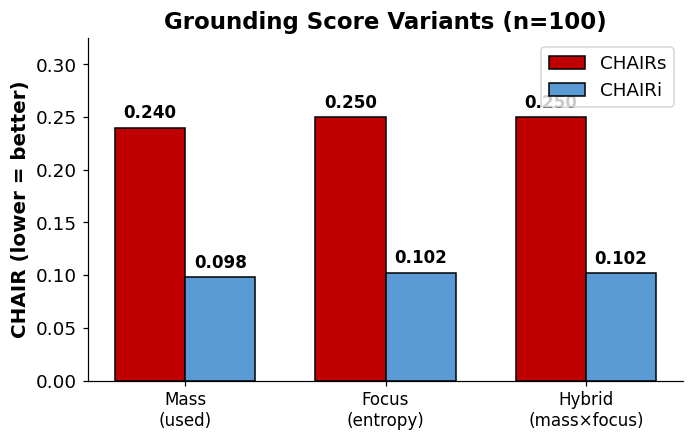


All figures saved to: /content/drive/MyDrive/llava_hallucination_heads/poster_figures
  fig1_chairs_bars.pdf  (23 KB)
  fig1_chairs_bars.png  (104 KB)
  fig2_chairi_bars.pdf  (22 KB)
  fig2_chairi_bars.png  (121 KB)
  fig3_length_recall.pdf  (26 KB)
  fig3_length_recall.png  (148 KB)
  fig4_theta_sweep.pdf  (19 KB)
  fig4_theta_sweep.png  (127 KB)
  fig5_heads_ablation.pdf  (18 KB)
  fig5_heads_ablation.png  (94 KB)
  fig6_scoring_mode.pdf  (25 KB)
  fig6_scoring_mode.png  (120 KB)


In [ ]:
# === POSTER FIGURE GENERATION ===
# Loads saved JSON results from Drive and generates publication-quality bar charts.
# No GPU needed. ~30 sec total.

import json, os
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
FIG_DIR  = f'{WORK_DIR}/poster_figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
})

COLORS = {'baseline':'#888888','stage2':'#5b9bd5','stage3':'#ed7d31','stage4':'#c00000'}
LABELS = {'baseline':'Baseline','stage2':'LoRA\nonly','stage3':'Grounding\nonly','stage4':'LoRA +\nGrounding'}
conds  = ['baseline','stage2','stage3','stage4']

# Load main results
with open(f'{WORK_DIR}/results/stage4_400img_results.json') as f:
    main = json.load(f)

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def bar_with_labels(ax, labels, values, colors, fmt='{:.3f}', y_pad=0.005):
    bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + y_pad, fmt.format(v),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    return bars

# ========== Figure 1: CHAIRs (HEADLINE) ==========
fig, ax = plt.subplots(figsize=(6.5, 4.2))
labels = [LABELS[c] for c in conds]
colors = [COLORS[c] for c in conds]
vals   = [main['chair'][c]['CHAIRs'] for c in conds]
bar_with_labels(ax, labels, vals, colors)
rel_red = (1 - vals[3]/vals[0]) * 100
ax.text(3, vals[3] + 0.05, f'−{rel_red:.0f}%', ha='center', fontsize=18,
        fontweight='bold', color='#c00000')
ax.set_ylabel('CHAIRs (lower = better)', fontweight='bold')
ax.set_title('Caption-Level Hallucination Rate (n=400)', fontweight='bold')
ax.set_ylim(0, max(vals) * 1.3)
style_axes(ax)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_chairs_bars.png')
plt.savefig(f'{FIG_DIR}/fig1_chairs_bars.pdf')
plt.show()

# ========== Figure 2: CHAIRi ==========
fig, ax = plt.subplots(figsize=(6.5, 4.2))
vals = [main['chair'][c]['CHAIRi'] for c in conds]
bar_with_labels(ax, labels, vals, colors, y_pad=0.003)
rel_red = (1 - vals[3]/vals[0]) * 100
ax.text(3, vals[3] + 0.022, f'−{rel_red:.0f}%', ha='center', fontsize=18,
        fontweight='bold', color='#c00000')
ax.set_ylabel('CHAIRi (lower = better)', fontweight='bold')
ax.set_title('Object-Level Hallucination Rate (n=400)', fontweight='bold')
ax.set_ylim(0, max(vals) * 1.3)
style_axes(ax)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_chairi_bars.png')
plt.savefig(f'{FIG_DIR}/fig2_chairi_bars.pdf')
plt.show()

# ========== Figure 3: Length + Recall (HONESTY figure) ==========
with open(f'{WORK_DIR}/results/stage4_length_recall.json') as f:
    lr = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
lens = [lr[c]['avg_length'] for c in conds]
recs = [lr[c]['avg_recall'] for c in conds]

bar_with_labels(axes[0], labels, lens, colors, fmt='{:.1f}', y_pad=1.0)
axes[0].set_ylabel('Avg Caption Length (words)', fontweight='bold')
axes[0].set_title('Caption Length', fontweight='bold')
axes[0].set_ylim(0, max(lens) * 1.15)
style_axes(axes[0])

bar_with_labels(axes[1], labels, recs, colors, fmt='{:.2f}', y_pad=0.015)
axes[1].axhline(y=recs[0], color='#888888', linestyle='--', alpha=0.6, linewidth=1.5)
axes[1].set_ylabel('GT-Object Recall', fontweight='bold')
axes[1].set_title('GT-Object Recall', fontweight='bold')
axes[1].set_ylim(0, 1.0)
style_axes(axes[1])

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_length_recall.png')
plt.savefig(f'{FIG_DIR}/fig3_length_recall.pdf')
plt.show()

# ========== Figure 4: Theta sweep ==========
td = main['theta_ablation']
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot([t['theta'] for t in td], [t['CHAIRs'] for t in td],
        'o-', color='#c00000', linewidth=2.5, markersize=11, label='CHAIRs')
ax.plot([t['theta'] for t in td], [t['CHAIRi'] for t in td],
        's-', color='#5b9bd5', linewidth=2.5, markersize=11, label='CHAIRi')
ax.set_xlabel('θ (grounding threshold)', fontweight='bold')
ax.set_ylabel('CHAIR (lower = better)', fontweight='bold')
ax.set_title('Robust to Threshold Choice (n=100)', fontweight='bold')
ax.legend(loc='upper right', frameon=True, fontsize=12)
ax.grid(True, alpha=0.3)
style_axes(ax)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_theta_sweep.png')
plt.savefig(f'{FIG_DIR}/fig4_theta_sweep.pdf')
plt.show()

# ========== Figure 5: Heads ablation ==========
hd = main['heads_ablation']
labels_h = [h['n_heads'] for h in hd]
chairs_h = [h['CHAIRs'] for h in hd]
chairi_h = [h['CHAIRi'] for h in hd]

x, w = np.arange(len(labels_h)), 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.2))
b1 = ax.bar(x - w/2, chairs_h, w, label='CHAIRs', color='#c00000', edgecolor='black')
b2 = ax.bar(x + w/2, chairi_h, w, label='CHAIRi', color='#5b9bd5', edgecolor='black')
for bar, v in zip(b1, chairs_h):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, v in zip(b2, chairi_h):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_h, fontsize=12)
ax.set_ylabel('CHAIR (lower = better)', fontweight='bold')
ax.set_title('Head-Count Ablation (n=100)', fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.set_ylim(0, max(chairs_h) * 1.3)
style_axes(ax)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_heads_ablation.png')
plt.savefig(f'{FIG_DIR}/fig5_heads_ablation.pdf')
plt.show()

# ========== Figure 6: Scoring mode (mass/focus/hybrid) — if available ==========
sm_path = f'{WORK_DIR}/results/stage4_scoring_mode_ablation.json'
if os.path.exists(sm_path):
    with open(sm_path) as f:
        sm = json.load(f)
    modes = ['mass','focus','hybrid']
    chairs_m = [sm[m]['CHAIRs'] for m in modes]
    chairi_m = [sm[m]['CHAIRi'] for m in modes]
    x = np.arange(len(modes))
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    b1 = ax.bar(x - w/2, chairs_m, w, label='CHAIRs', color='#c00000', edgecolor='black')
    b2 = ax.bar(x + w/2, chairi_m, w, label='CHAIRi', color='#5b9bd5', edgecolor='black')
    for bar, v in zip(b1, chairs_m):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    for bar, v in zip(b2, chairi_m):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Mass\n(used)','Focus\n(entropy)','Hybrid\n(mass×focus)'], fontsize=11)
    ax.set_ylabel('CHAIR (lower = better)', fontweight='bold')
    ax.set_title('Grounding Score Variants (n=100)', fontweight='bold')
    ax.legend(loc='upper right', fontsize=12)
    ax.set_ylim(0, max(chairs_m) * 1.3)
    style_axes(ax)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig6_scoring_mode.png')
    plt.savefig(f'{FIG_DIR}/fig6_scoring_mode.pdf')
    plt.show()

print(f'\nAll figures saved to: {FIG_DIR}')
for f in sorted(os.listdir(FIG_DIR)):
    sz = os.path.getsize(f'{FIG_DIR}/{f}') / 1024
    print(f'  {f}  ({sz:.0f} KB)')

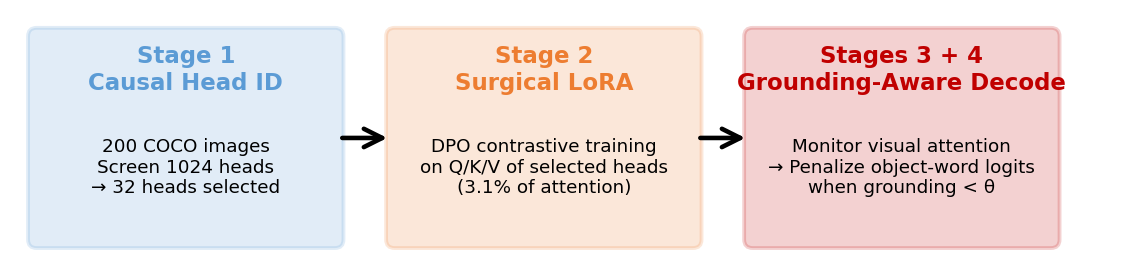

Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram1_pipeline.png


In [ ]:
import json, os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
FIG_DIR  = f'{WORK_DIR}/poster_figures'
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({'savefig.dpi': 300, 'savefig.bbox': 'tight',
                     'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(0, 13); ax.set_ylim(0, 3); ax.axis('off')

stages = [
    ("Stage 1\nCausal Head ID",
     "200 COCO images\nScreen 1024 heads\n→ 32 heads selected"),
    ("Stage 2\nSurgical LoRA",
     "DPO contrastive training\non Q/K/V of selected heads\n(3.1% of attention)"),
    ("Stages 3 + 4\nGrounding-Aware Decode",
     "Monitor visual attention\n→ Penalize object-word logits\nwhen grounding < θ"),
]
colors = ['#5b9bd5', '#ed7d31', '#c00000']
box_w, box_h, y_box = 3.5, 2.4, 0.3

for i, ((title, body), color) in enumerate(zip(stages, colors)):
    x = 0.3 + i * 4.2
    ax.add_patch(FancyBboxPatch((x, y_box), box_w, box_h, boxstyle="round,pad=0.1",
                                  linewidth=2.5, edgecolor=color, facecolor=color, alpha=0.18))
    ax.text(x + box_w/2, y_box + box_h - 0.4, title, ha='center', va='center',
            fontsize=15, fontweight='bold', color=color)
    ax.text(x + box_w/2, y_box + 0.85, body, ha='center', va='center', fontsize=12)
    if i < 2:
        ax.add_patch(FancyArrowPatch((x + box_w + 0.05, y_box + box_h/2),
                                       (x + box_w + 0.65, y_box + box_h/2),
                                       arrowstyle='->', mutation_scale=30,
                                       linewidth=3, color='black'))
plt.savefig(f'{FIG_DIR}/diagram1_pipeline.png')
plt.show()
print(f'Saved: {FIG_DIR}/diagram1_pipeline.png')

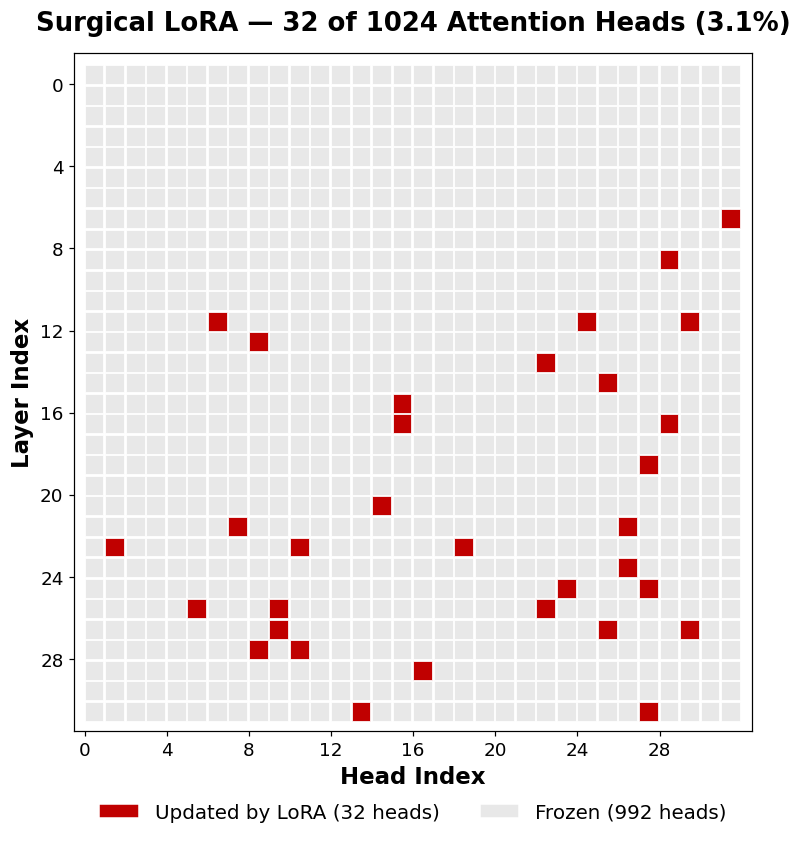

Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram2_surgical_lora_grid.png


In [ ]:
with open(f'{WORK_DIR}/results/final_hallucination_heads.json') as f:
    heads = json.load(f)
selected = {(h['layer'], h['head']) for h in heads}

NUM_LAYERS, NUM_HEADS = 32, 32
fig, ax = plt.subplots(figsize=(11, 8))

for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        is_sel = (layer, head) in selected
        color = '#c00000' if is_sel else '#e8e8e8'
        ax.add_patch(Rectangle((head, NUM_LAYERS - 1 - layer), 0.92, 0.92,
                               facecolor=color, edgecolor='white', linewidth=0.5))

ax.set_xlim(-0.5, NUM_HEADS + 0.5)
ax.set_ylim(-0.5, NUM_LAYERS + 0.5)
ax.set_xlabel('Head Index', fontweight='bold', fontsize=15)
ax.set_ylabel('Layer Index', fontweight='bold', fontsize=15)
ax.set_title('Surgical LoRA — 32 of 1024 Attention Heads (3.1%)',
              fontweight='bold', fontsize=17, pad=15)
ax.set_xticks(range(0, NUM_HEADS, 4))
ax.set_yticks([NUM_LAYERS - 1 - i for i in range(0, NUM_LAYERS, 4)])
ax.set_yticklabels(range(0, NUM_LAYERS, 4))
ax.set_aspect('equal')

ax.legend([Rectangle((0,0), 1, 1, facecolor='#c00000', edgecolor='white'),
           Rectangle((0,0), 1, 1, facecolor='#e8e8e8', edgecolor='white')],
          ['Updated by LoRA (32 heads)', 'Frozen (992 heads)'],
          loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2,
          fontsize=13, frameon=False)
plt.savefig(f'{FIG_DIR}/diagram2_surgical_lora_grid.png')
plt.show()
print(f'Saved: {FIG_DIR}/diagram2_surgical_lora_grid.png')

In [ ]:
import re, json, os
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
with open(f'{WORK_DIR}/cache/stage4_400img_ckpt.json') as f:
    eval_records = json.load(f)

COCO_SYNONYMS = {
    'person':['man','woman','people','boy','girl','child','guy','lady','kid','baby','player','rider','skier','surfer','snowboarder'],
    'car':['vehicle','automobile','sedan','suv'],'dog':['puppy','dogs'],'cat':['kitten','cats'],
    'tv':['television','monitor','screen'],'couch':['sofa'],'cell phone':['phone','cellphone','smartphone'],
    'dining table':['table','desk'],'wine glass':['glass'],'bicycle':['bike'],'motorcycle':['motorbike'],
    'airplane':['plane','jet'],'potted plant':['plant'],'laptop':['computer'],'refrigerator':['fridge'],
    'truck':['lorry'],'boat':['ship','sailboat'],'fire hydrant':['hydrant'],'hot dog':['hotdog'],
    'traffic light':['stoplight'],'sports ball':['ball','football','soccer ball','basketball'],
    'baseball bat':['bat'],'tennis racket':['racket','racquet'],
}
ALL_COCO = set(COCO_SYNONYMS.keys()) | {s for v in COCO_SYNONYMS.values() for s in v} | \
           {'bird','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella',
            'handbag','tie','suitcase','frisbee','skis','snowboard','kite','skateboard','surfboard',
            'bottle','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
            'broccoli','carrot','pizza','donut','cake','chair','bed','toilet','mouse','remote',
            'keyboard','microwave','oven','toaster','sink','book','clock','vase','scissors',
            'teddy bear','hair drier','toothbrush','bench','stop sign','parking meter'}

def count_halluc(caption, gt_set):
    expanded_gt = set(o.lower() for o in gt_set)
    for canon, syns in COCO_SYNONYMS.items():
        if canon in expanded_gt: expanded_gt.update(syns)
    return {w.lower() for w in re.findall(r'\b[a-zA-Z]+\b', caption)
            if w.lower() in ALL_COCO and w.lower() not in expanded_gt}

# --- Tunable thresholds ---
MIN_OURS_LEN     = 15   # Ours caption needs at least 15 words (avoid 4-word stubs)
MIN_BASELINE_LEN = 30   # Baseline at least 30 words for visual impact
REQUIRE_DIFF     = True # Ours caption must differ from LoRA-only

candidates = []
for r in eval_records:
    gt_set   = set(r['gt'])
    cap_b    = r['captions'].get('baseline', '')
    cap_l    = r['captions'].get('stage2',   '')
    cap_g    = r['captions'].get('stage3',   '')
    cap_o    = r['captions'].get('stage4',   '')

    # Length filters
    if len(cap_o.split()) < MIN_OURS_LEN: continue
    if len(cap_b.split()) < MIN_BASELINE_LEN: continue
    if len(cap_l.split()) < 10: continue
    if len(cap_g.split()) < 10: continue

    # Diff filter
    if REQUIRE_DIFF and cap_l.strip().lower() == cap_o.strip().lower(): continue

    h_b = count_halluc(cap_b, gt_set)
    h_l = count_halluc(cap_l, gt_set)
    h_g = count_halluc(cap_g, gt_set)
    h_o = count_halluc(cap_o, gt_set)

    # We want ALL three other methods to hallucinate, Ours strictly fewer
    if not (len(h_b) >= 1 and len(h_l) >= 1 and len(h_g) >= 1):
        continue
    others_min = min(len(h_b), len(h_l), len(h_g))
    if not (len(h_o) < others_min):
        continue

    # Score: prioritize big margins + reasonable caption lengths
    score = (others_min - len(h_o)) * 10 + len(cap_o.split()) / 10

    candidates.append({
        'img_id': r['img_id'], 'gt': sorted(gt_set), 'score': score,
        'h_b': sorted(h_b), 'h_l': sorted(h_l), 'h_g': sorted(h_g), 'h_o': sorted(h_o),
        'cap_b': cap_b, 'cap_l': cap_l, 'cap_g': cap_g, 'cap_o': cap_o,
    })

candidates.sort(key=lambda x: -x['score'])
print(f'\nFound {len(candidates)} strong candidates.\n')
print(f'Filters: ours_len ≥ {MIN_OURS_LEN}, baseline_len ≥ {MIN_BASELINE_LEN}, '
      f'all 3 others hallucinate ≥ 1, Ours hallucinates strictly fewer, ours ≠ LoRA caption.\n')

print('=' * 88)
for c in candidates[:8]:
    print(f"\n► IMG_ID = {c['img_id']}   score={c['score']:.1f}")
    print(f"  GT objects: {', '.join(c['gt'])}")
    print(f"  Baseline   ({len(c['cap_b'].split()):3d}w):  hallucinated: {', '.join(c['h_b']) or '(none)'}")
    print(f"    \"{c['cap_b'][:120]}...\"")
    print(f"  LoRA       ({len(c['cap_l'].split()):3d}w):  hallucinated: {', '.join(c['h_l']) or '(none)'}")
    print(f"    \"{c['cap_l'][:120]}...\"")
    print(f"  Grounding  ({len(c['cap_g'].split()):3d}w):  hallucinated: {', '.join(c['h_g']) or '(none)'}")
    print(f"    \"{c['cap_g'][:120]}...\"")
    print(f"  Ours       ({len(c['cap_o'].split()):3d}w):  hallucinated: {', '.join(c['h_o']) or '(none)'}")
    print(f"    \"{c['cap_o'][:120]}...\"")
print('\n' + '=' * 88)


Found 7 strong candidates.

Filters: ours_len ≥ 15, baseline_len ≥ 30, all 3 others hallucinate ≥ 1, Ours hallucinates strictly fewer, ours ≠ LoRA caption.


► IMG_ID = 198928   score=14.7
  GT objects: bus, car, person, traffic light
  Baseline   ( 70w):  hallucinated: backpack
    "The scene features a woman standing on the sidewalk near an intersection, waiting for her turn to cross the street at th..."
  LoRA       ( 36w):  hallucinated: backpack
    "A woman standing on a street corner with traffic lights above her head and buildings behind her. She is wearing blue jea..."
  Grounding  ( 67w):  hallucinated: backpack
    "The image features a woman standing on the sidewalk near an intersection. She is wearing blue jeans and has her backpack..."
  Ours       ( 47w):  hallucinated: (none)
    "A woman standing on a street corner with traffic lights. A green light is lit up and she has her back turned to the came..."

► IMG_ID = 92826   score=13.8
  GT objects: bowl, vase
  Baseline

Generating 7 qualitative example figures...



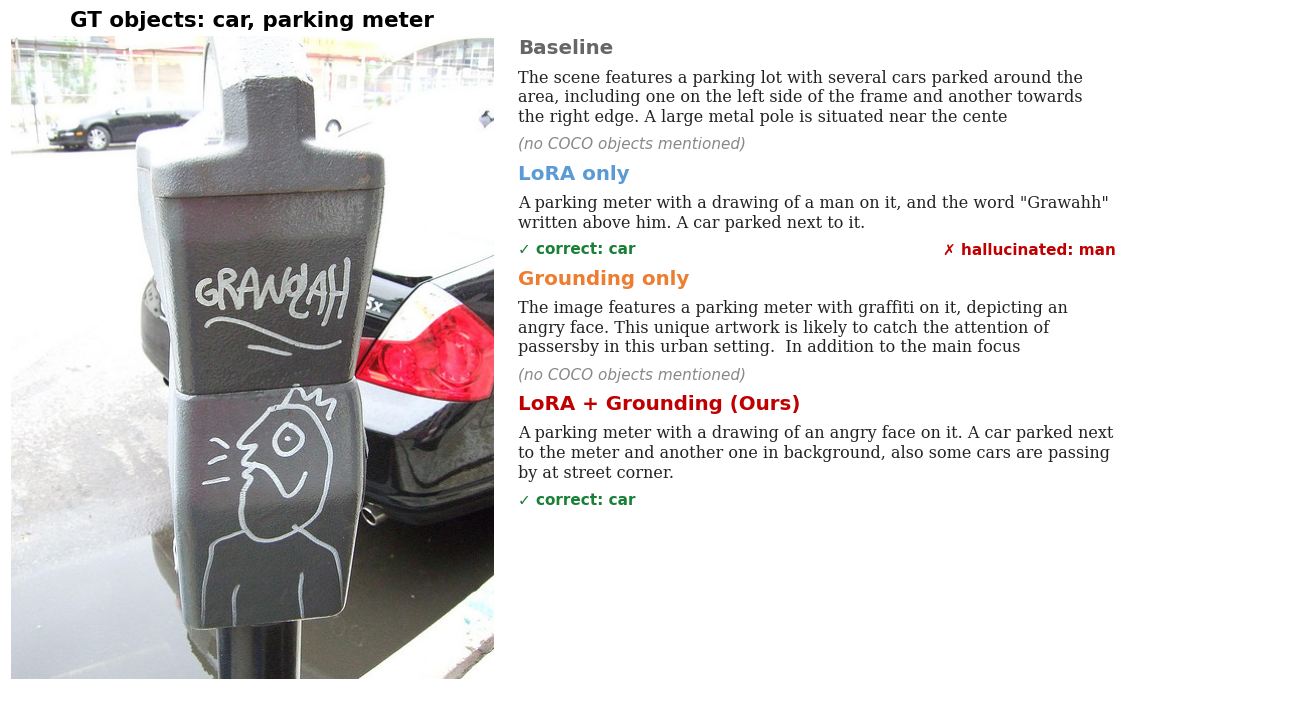

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_577096.png


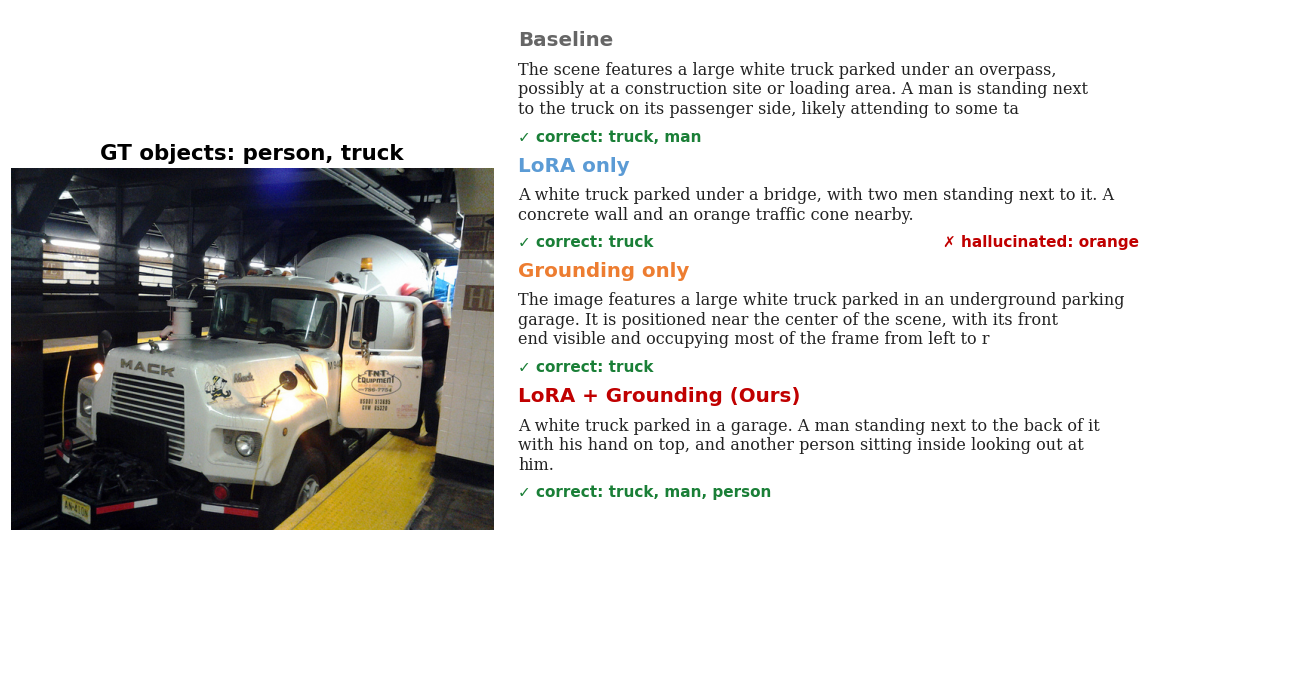

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_130516.png


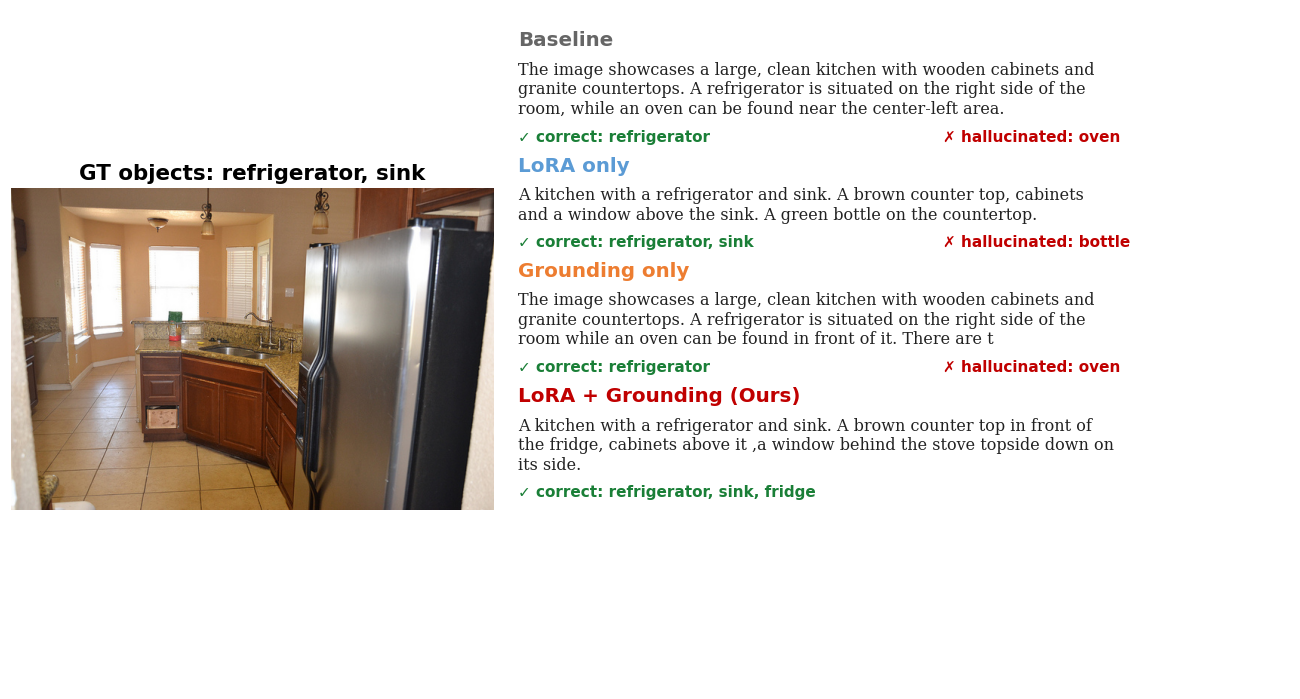

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_452793.png


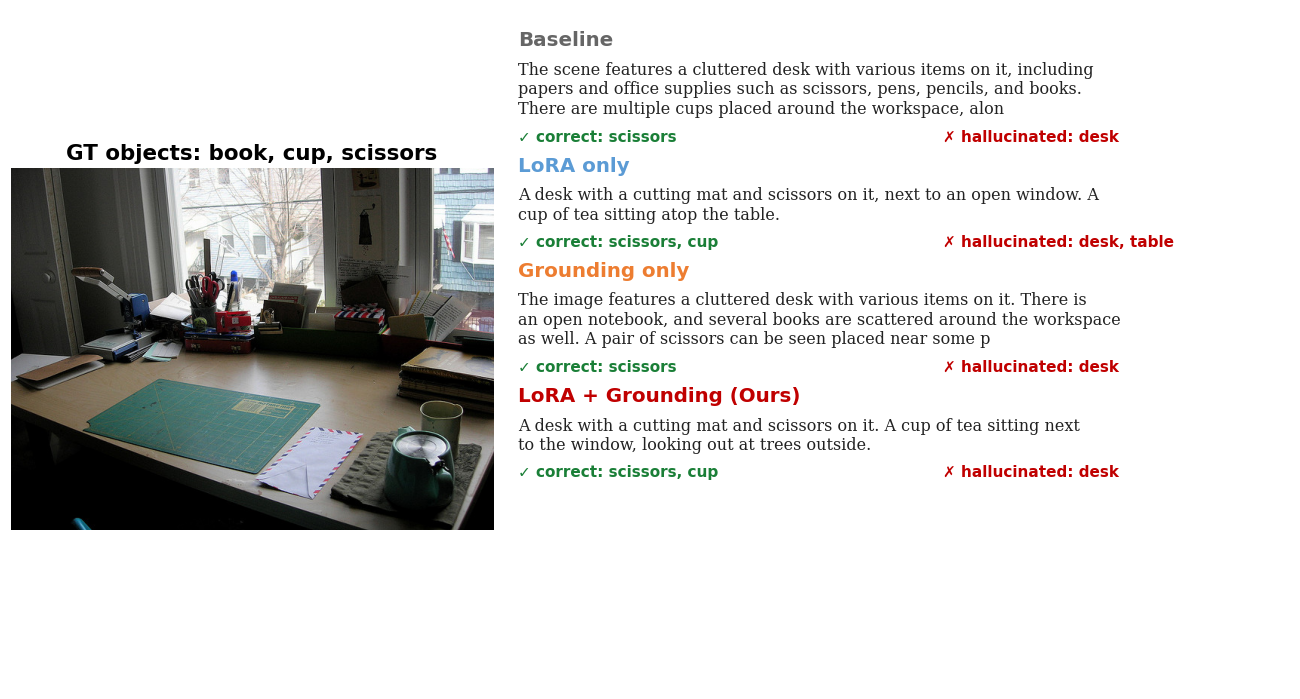

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_152751.png


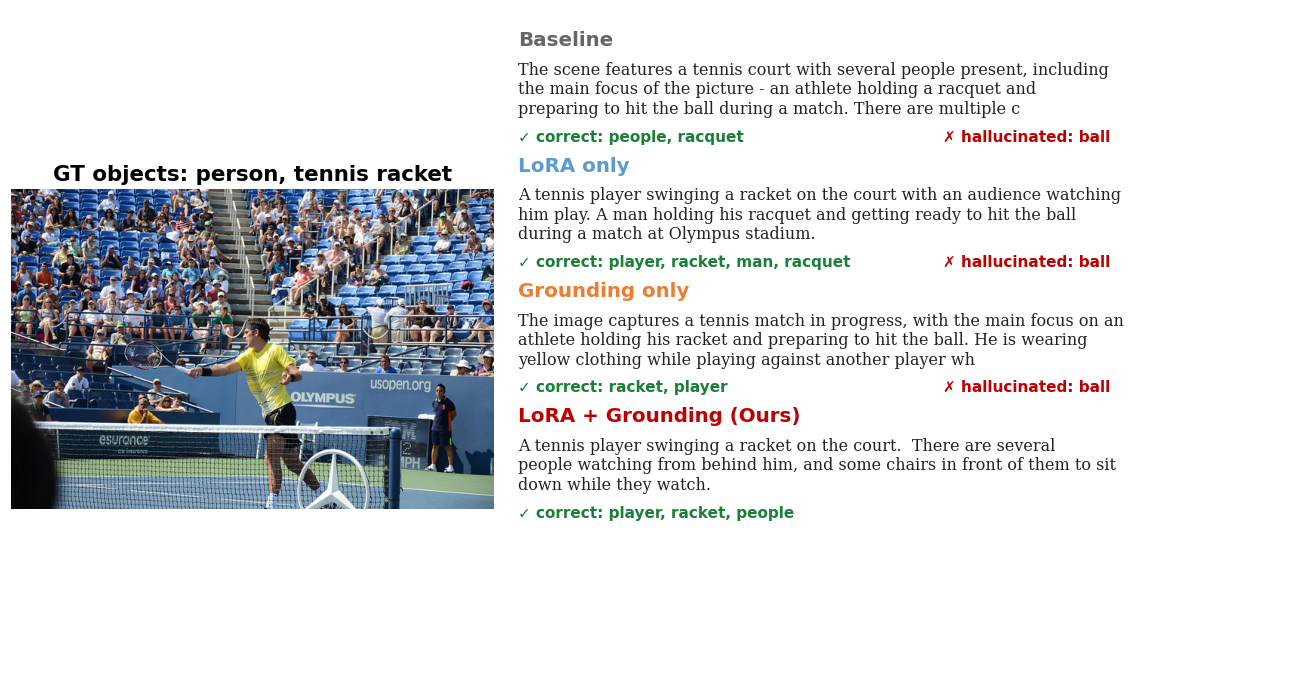

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_143572.png


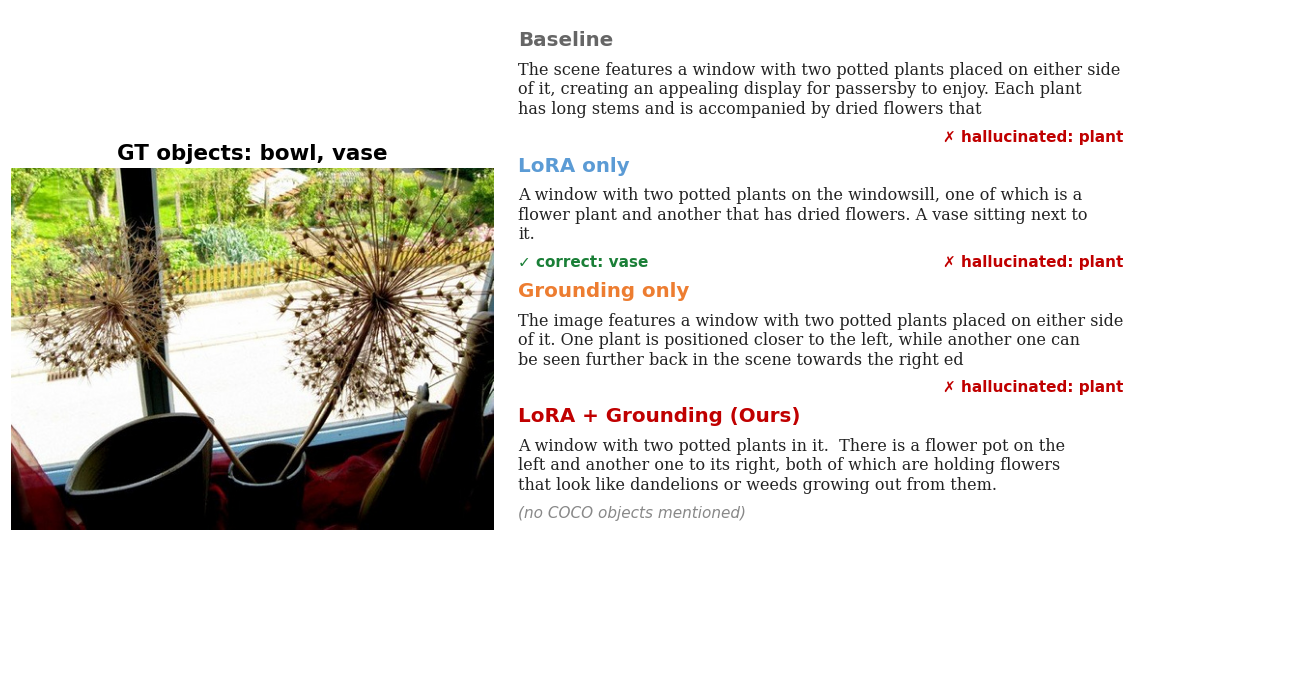

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_92826.png


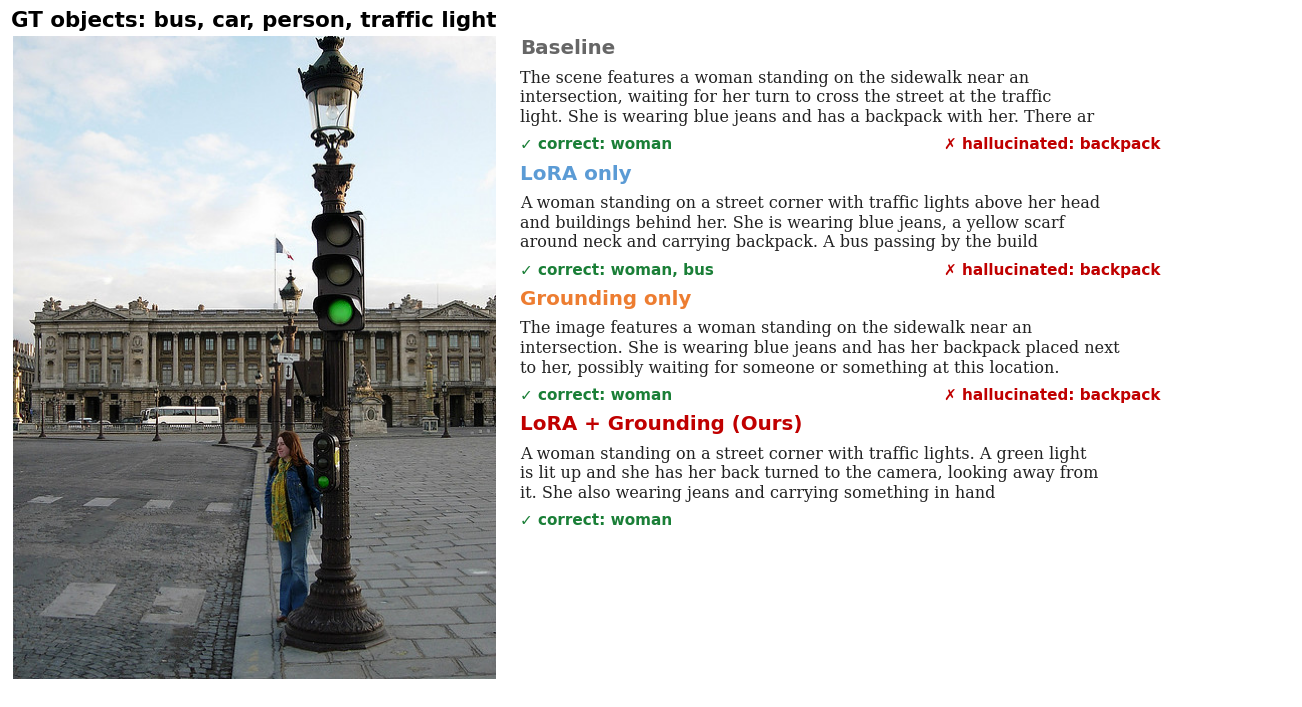

  Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram4_qualitative_198928.png

Done. 7/7 figures saved to /content/drive/MyDrive/llava_hallucination_heads/poster_figures/


In [ ]:
import re, textwrap, json, os
from PIL import Image as PILImage
import matplotlib.pyplot as plt

with open(f'{WORK_DIR}/cache/stage4_400img_ckpt.json') as f:
    eval_records = json.load(f)

# === Edit this list with the IMG_IDs you want to generate figures for ===
IMG_IDS = [
    577096,
    130516,
    452793,
    152751,
    143572,
    92826,
    198928
]

# Inline COCO synonyms + object vocab
COCO_SYNONYMS = {
    'person':['man','woman','people','boy','girl','child','guy','lady','kid','baby','player','rider','skier','surfer','snowboarder'],
    'car':['vehicle','automobile','sedan','suv'],'dog':['puppy','dogs'],'cat':['kitten','cats'],
    'tv':['television','monitor','screen'],'couch':['sofa'],'cell phone':['phone','cellphone','smartphone'],
    'dining table':['table','desk'],'wine glass':['glass'],'bicycle':['bike'],'motorcycle':['motorbike'],
    'airplane':['plane','jet'],'potted plant':['plant'],'laptop':['computer'],'refrigerator':['fridge'],
    'truck':['lorry'],'boat':['ship','sailboat'],'fire hydrant':['hydrant'],'hot dog':['hotdog'],
    'traffic light':['stoplight'],'sports ball':['ball','football','soccer ball','basketball'],
    'baseball bat':['bat'],'tennis racket':['racket','racquet'],
}
ALL_COCO = set(COCO_SYNONYMS.keys()) | {s for v in COCO_SYNONYMS.values() for s in v} | \
           {'bird','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella',
            'handbag','tie','suitcase','frisbee','skis','snowboard','kite','skateboard','surfboard',
            'bottle','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
            'broccoli','carrot','pizza','donut','cake','chair','bed','toilet','mouse','remote',
            'keyboard','microwave','oven','toaster','sink','book','clock','vase','scissors',
            'teddy bear','hair drier','toothbrush','bench','stop sign','parking meter'}

def analyze_caption(caption, gt_set):
    expanded_gt = set(o.lower() for o in gt_set)
    for canon, syns in COCO_SYNONYMS.items():
        if canon in expanded_gt: expanded_gt.update(syns)
    correct_set, halluc_set, seen = [], [], set()
    for word in re.findall(r'\b[a-zA-Z]+\b', caption):
        w = word.lower()
        if w in seen: continue
        seen.add(w)
        if w in expanded_gt:        correct_set.append(w)
        elif w in ALL_COCO:         halluc_set.append(w)
    return correct_set, halluc_set


def render_qualitative(img_id):
    """Build a single qualitative-example figure for one image and save it."""
    record = next((r for r in eval_records if r['img_id'] == img_id), None)
    if record is None:
        print(f'  [skip] img {img_id}: not in eval records')
        return False

    img_path = f'{WORK_DIR}/coco/val2014_subset/COCO_val2014_{img_id:012d}.jpg'
    if not os.path.exists(img_path):
        print(f'  [skip] img {img_id}: image file not found')
        return False

    gt_set = set(record['gt'])
    img = PILImage.open(img_path).convert('RGB')

    fig = plt.figure(figsize=(15, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.04)

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(img); ax_img.axis('off')
    ax_img.set_title(f'GT objects: {", ".join(sorted(gt_set))}',
                      fontsize=14, fontweight='bold')

    ax_cap = fig.add_subplot(gs[1])
    ax_cap.axis('off')
    ax_cap.set_xlim(0, 1); ax_cap.set_ylim(0, 1)

    cond_labels = {'baseline':'Baseline','stage2':'LoRA only',
                   'stage3':'Grounding only','stage4':'LoRA + Grounding (Ours)'}
    cond_colors = {'baseline':'#666666','stage2':'#5b9bd5',
                   'stage3':'#ed7d31','stage4':'#c00000'}

    y_cur = 0.97
    for cond in ['baseline','stage2','stage3','stage4']:
        cap = record['captions'].get(cond, '')[:200]

        ax_cap.text(0.0, y_cur, cond_labels[cond], fontsize=13,
                    fontweight='bold', color=cond_colors[cond],
                    transform=ax_cap.transAxes, verticalalignment='top')
        y_cur -= 0.045

        wrapped = textwrap.fill(cap, width=72)
        n_lines = wrapped.count('\n') + 1
        ax_cap.text(0.0, y_cur, wrapped, fontsize=10.5, color='#222222',
                    transform=ax_cap.transAxes, verticalalignment='top',
                    family='serif')
        y_cur -= n_lines * 0.030 + 0.010

        correct, halluc = analyze_caption(cap, gt_set)
        if correct:
            ax_cap.text(0.0, y_cur, '✓ correct: ' + ', '.join(correct),
                        fontsize=10, color='#1a7f37', fontweight='bold',
                        transform=ax_cap.transAxes, verticalalignment='top')
        if halluc:
            ax_cap.text(0.55, y_cur, '✗ hallucinated: ' + ', '.join(halluc),
                        fontsize=10, color='#c00000', fontweight='bold',
                        transform=ax_cap.transAxes, verticalalignment='top')
        if not correct and not halluc:
            ax_cap.text(0.0, y_cur, '(no COCO objects mentioned)',
                        fontsize=10, color='#888888', style='italic',
                        transform=ax_cap.transAxes, verticalalignment='top')
        y_cur -= 0.04

    out_path = f'{FIG_DIR}/diagram4_qualitative_{img_id}.png'
    plt.savefig(out_path)
    plt.show()
    plt.close(fig)
    print(f'  Saved: {out_path}')
    return True


print(f'Generating {len(IMG_IDS)} qualitative example figures...\n')
ok = sum(render_qualitative(i) for i in IMG_IDS)
print(f'\nDone. {ok}/{len(IMG_IDS)} figures saved to {FIG_DIR}/')

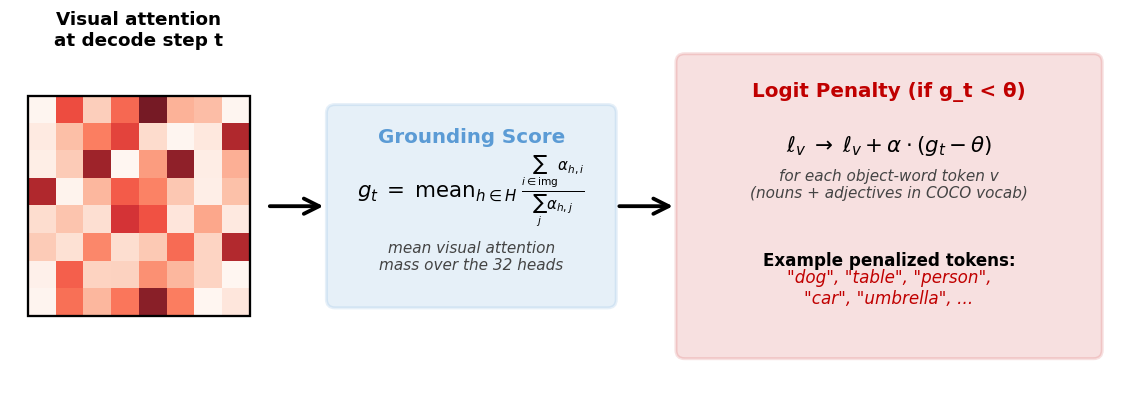

Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram3_grounding_score.png


In [ ]:
import os, json
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
FIG_DIR  = f'{WORK_DIR}/poster_figures'
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({'savefig.dpi': 300, 'savefig.bbox': 'tight',
                     'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.5); ax.axis('off')

# Box 1: attention heatmap
np.random.seed(7)
ax.text(1.5, 4.2, 'Visual attention\nat decode step t', ha='center',
        fontsize=12, fontweight='bold')
attn = np.random.rand(8, 8) ** 2
attn = attn / attn.max()
ax.imshow(attn, extent=(0.2, 2.8, 1.0, 3.6), cmap='Reds', aspect='auto', alpha=0.9)
ax.add_patch(Rectangle((0.2, 1.0), 2.6, 2.6, fill=False, edgecolor='black', linewidth=1.5))

ax.add_patch(FancyArrowPatch((3.0, 2.3), (3.7, 2.3), arrowstyle='->',
                              mutation_scale=25, linewidth=2.5))

# Box 2: Grounding score (no \mathrel, simpler formula)
ax.add_patch(FancyBboxPatch((3.8, 1.2), 3.2, 2.2, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#5b9bd5',
                             facecolor='#5b9bd5', alpha=0.15))
ax.text(5.4, 3.05, 'Grounding Score', ha='center', fontsize=13,
        fontweight='bold', color='#5b9bd5')
ax.text(5.4, 2.4, r'$g_t \;=\; \mathrm{mean}_{h \in H}\;\frac{\sum_{i \in \mathrm{img}} \alpha_{h,i}}{\sum_j \alpha_{h,j}}$',
        ha='center', fontsize=14)
ax.text(5.4, 1.55, 'mean visual attention\nmass over the 32 heads',
        ha='center', fontsize=10, style='italic', color='#444444')

ax.add_patch(FancyArrowPatch((7.1, 2.3), (7.8, 2.3), arrowstyle='->',
                              mutation_scale=25, linewidth=2.5))

# Box 3: penalty (rewrite the formula)
ax.add_patch(FancyBboxPatch((7.9, 0.6), 4.8, 3.4, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#c00000',
                             facecolor='#c00000', alpha=0.12))
ax.text(10.3, 3.6, 'Logit Penalty (if g_t < θ)', ha='center', fontsize=13,
        fontweight='bold', color='#c00000')
ax.text(10.3, 2.95, r'$\ell_v \;\to\; \ell_v + \alpha \cdot (g_t - \theta)$',
        ha='center', fontsize=14)
ax.text(10.3, 2.4, 'for each object-word token v\n(nouns + adjectives in COCO vocab)',
        ha='center', fontsize=10, style='italic', color='#444444')
ax.text(10.3, 1.6, 'Example penalized tokens:', ha='center',
        fontsize=11, fontweight='bold')
ax.text(10.3, 1.15, '"dog", "table", "person",\n"car", "umbrella", ...',
        ha='center', fontsize=11, color='#c00000', style='italic')

plt.savefig(f'{FIG_DIR}/diagram3_grounding_score.png')
plt.show()
print(f'Saved: {FIG_DIR}/diagram3_grounding_score.png')

In [ ]:
import re, json, os
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'

with open(f'{WORK_DIR}/cache/stage4_400img_ckpt.json') as f:
    eval_records = json.load(f)

COCO_SYNONYMS = {
    'person':['man','woman','people','boy','girl','child','guy','lady','kid','baby','player','rider','skier','surfer','snowboarder'],
    'car':['vehicle','automobile','sedan','suv'],'dog':['puppy','dogs'],'cat':['kitten','cats'],
    'tv':['television','monitor','screen'],'couch':['sofa'],'cell phone':['phone','cellphone','smartphone'],
    'dining table':['table','desk'],'wine glass':['glass'],'bicycle':['bike'],'motorcycle':['motorbike'],
    'airplane':['plane','jet'],'potted plant':['plant'],'laptop':['computer'],'refrigerator':['fridge'],
    'truck':['lorry'],'boat':['ship','sailboat'],'fire hydrant':['hydrant'],'hot dog':['hotdog'],
    'traffic light':['stoplight'],'sports ball':['ball','football','soccer ball','basketball'],
    'baseball bat':['bat'],'tennis racket':['racket','racquet'],
}
ALL_COCO = set(COCO_SYNONYMS.keys()) | {s for v in COCO_SYNONYMS.values() for s in v} | \
           {'bird','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella',
            'handbag','tie','suitcase','frisbee','skis','snowboard','kite','skateboard','surfboard',
            'bottle','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
            'broccoli','carrot','pizza','donut','cake','chair','bed','toilet','mouse','remote',
            'keyboard','microwave','oven','toaster','sink','book','clock','vase','scissors',
            'teddy bear','hair drier','toothbrush','bench','stop sign','parking meter'}

def count_halluc(caption, gt_set):
    expanded_gt = set(o.lower() for o in gt_set)
    for canon, syns in COCO_SYNONYMS.items():
        if canon in expanded_gt: expanded_gt.update(syns)
    halluc = set()
    for word in re.findall(r'\b[a-zA-Z]+\b', caption):
        w = word.lower()
        if w in ALL_COCO and w not in expanded_gt:
            halluc.add(w)
    return halluc

# Score every image
candidates = []
for r in eval_records:
    gt_set = set(r['gt'])
    h_base    = count_halluc(r['captions'].get('baseline', ''), gt_set)
    h_stage2  = count_halluc(r['captions'].get('stage2', ''),   gt_set)
    h_stage3  = count_halluc(r['captions'].get('stage3', ''),   gt_set)
    h_ours    = count_halluc(r['captions'].get('stage4', ''),   gt_set)

    # We want: baseline + stage2 + stage3 all hallucinate, ours doesn't
    # Score = how much worse the others are than ours
    others_max = max(len(h_base), len(h_stage2), len(h_stage3))
    win_margin = others_max - len(h_ours)

    candidates.append({
        'img_id': r['img_id'], 'gt': sorted(gt_set),
        'h_base': sorted(h_base), 'h_stage2': sorted(h_stage2),
        'h_stage3': sorted(h_stage3), 'h_ours': sorted(h_ours),
        'win_margin': win_margin,
        'ours_clean': len(h_ours) == 0,
        'others_dirty': min(len(h_base), len(h_stage2), len(h_stage3)) > 0,
    })

# Filter: Ours must have 0 hallucinations, all 3 others must have ≥1
best = [c for c in candidates if c['ours_clean'] and c['others_dirty']]
best.sort(key=lambda x: -x['win_margin'])

print(f'\nFound {len(best)} clean-win candidates (Ours = 0 halluc, all others ≥ 1).\n')
print('Top 10 (ranked by win margin):')
print('=' * 78)
for c in best[:10]:
    print(f"\nIMG_ID = {c['img_id']}   margin = {c['win_margin']}")
    print(f"  GT objects: {', '.join(c['gt'])}")
    print(f"  Baseline hallucinated:  {', '.join(c['h_base'])  or '(none)'}")
    print(f"  LoRA hallucinated:      {', '.join(c['h_stage2']) or '(none)'}")
    print(f"  Grounding hallucinated: {', '.join(c['h_stage3']) or '(none)'}")
    print(f"  Ours hallucinated:      {', '.join(c['h_ours'])  or '(none)'}")
print('\n' + '=' * 78)
print('Pick an IMG_ID from above and use it in the qualitative example cell.')


Found 15 clean-win candidates (Ours = 0 halluc, all others ≥ 1).

Top 10 (ranked by win margin):

IMG_ID = 360400   margin = 4
  GT objects: cell phone, person
  Baseline hallucinated:  car, vehicle
  LoRA hallucinated:      car
  Grounding hallucinated: car, handbag, suv, vehicle
  Ours hallucinated:      (none)

IMG_ID = 287741   margin = 3
  GT objects: bird, keyboard, person
  Baseline hallucinated:  computer, desk
  LoRA hallucinated:      computer, mouse
  Grounding hallucinated: computer, desk, mouse
  Ours hallucinated:      (none)

IMG_ID = 1577   margin = 3
  GT objects: chair, vase
  Baseline hallucinated:  bottle, glass, table
  LoRA hallucinated:      table
  Grounding hallucinated: glass, table
  Ours hallucinated:      (none)

IMG_ID = 279085   margin = 3
  GT objects: laptop, person
  Baseline hallucinated:  chair, screen
  LoRA hallucinated:      chair, desk, table
  Grounding hallucinated: chair, screen
  Ours hallucinated:      (none)

IMG_ID = 105015   margin = 3
 

/tmp/ipykernel_3583/2681022215.py:85: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{FIG_DIR}/diagram_stage2_training.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


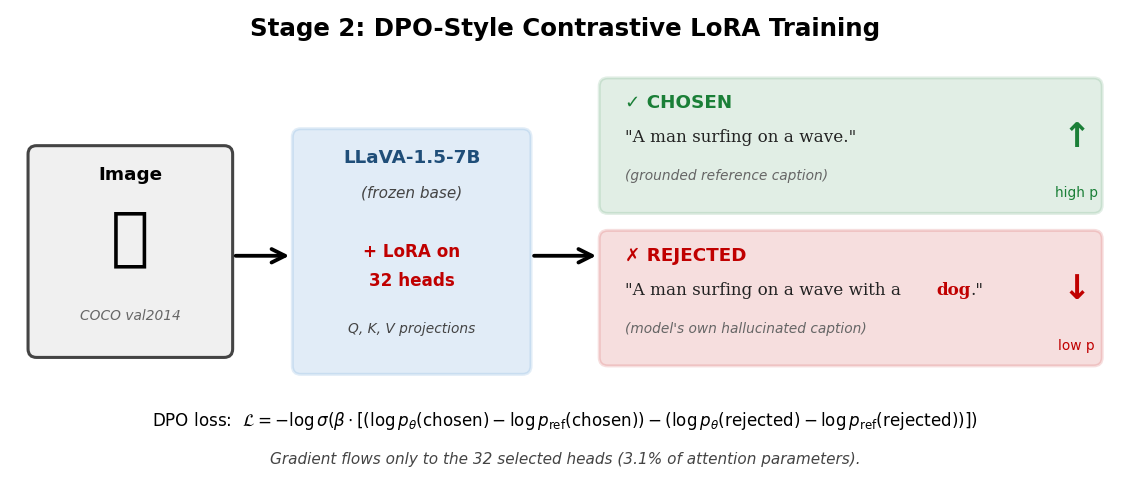

Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/diagram_stage2_training.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import os

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
FIG_DIR  = f'{WORK_DIR}/poster_figures'
os.makedirs(FIG_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis('off')

# Title
ax.text(6.5, 5.2, 'Stage 2: DPO-Style Contrastive LoRA Training',
        ha='center', fontsize=16, fontweight='bold')

# Left: image + model
ax.add_patch(FancyBboxPatch((0.3, 1.5), 2.2, 2.3, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#444444',
                             facecolor='#f0f0f0'))
ax.text(1.4, 3.5, 'Image', ha='center', fontsize=12, fontweight='bold')
ax.text(1.4, 2.6, '🖼️', ha='center', fontsize=42)
ax.text(1.4, 1.85, 'COCO val2014', ha='center', fontsize=9, style='italic', color='#666')

# Arrow into model
ax.add_patch(FancyArrowPatch((2.6, 2.6), (3.3, 2.6), arrowstyle='->',
                              mutation_scale=22, linewidth=2.5))

# Model box
ax.add_patch(FancyBboxPatch((3.4, 1.3), 2.6, 2.7, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#5b9bd5',
                             facecolor='#5b9bd5', alpha=0.18))
ax.text(4.7, 3.7, 'LLaVA-1.5-7B', ha='center', fontsize=12, fontweight='bold',
        color='#1f4e79')
ax.text(4.7, 3.3, '(frozen base)', ha='center', fontsize=10, style='italic',
        color='#444')
ax.text(4.7, 2.6, '+ LoRA on', ha='center', fontsize=11, fontweight='bold',
        color='#c00000')
ax.text(4.7, 2.25, '32 heads', ha='center', fontsize=11, fontweight='bold',
        color='#c00000')
ax.text(4.7, 1.7, 'Q, K, V projections', ha='center', fontsize=9,
        style='italic', color='#444')

# Arrow to pairs
ax.add_patch(FancyArrowPatch((6.1, 2.6), (6.9, 2.6), arrowstyle='->',
                              mutation_scale=22, linewidth=2.5))

# Right: chosen / rejected stack
# CHOSEN (top, green)
ax.add_patch(FancyBboxPatch((7.0, 3.2), 5.7, 1.4, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#1a7f37',
                             facecolor='#1a7f37', alpha=0.13))
ax.text(7.2, 4.35, '✓ CHOSEN', fontsize=12, fontweight='bold', color='#1a7f37')
ax.text(7.2, 3.95, '"A man surfing on a wave."', fontsize=11,
        family='serif', color='#222')
ax.text(7.2, 3.5, '(grounded reference caption)', fontsize=9, style='italic',
        color='#666')
ax.text(12.5, 3.9, '↑', fontsize=22, color='#1a7f37', ha='center', fontweight='bold')
ax.text(12.5, 3.3, 'high p', fontsize=9, color='#1a7f37', ha='center')

# REJECTED (bottom, red)
ax.add_patch(FancyBboxPatch((7.0, 1.4), 5.7, 1.4, boxstyle="round,pad=0.1",
                             linewidth=2, edgecolor='#c00000',
                             facecolor='#c00000', alpha=0.13))
ax.text(7.2, 2.55, '✗ REJECTED', fontsize=12, fontweight='bold', color='#c00000')
# Caption with inline color (use multiple text calls to keep it simple)
ax.text(7.2, 2.15, '"A man surfing on a wave with a ', fontsize=11,
        family='serif', color='#222')
ax.text(10.85, 2.15, 'dog', fontsize=11, family='serif', color='#c00000',
        fontweight='bold')
ax.text(11.25, 2.15, '."', fontsize=11, family='serif', color='#222')
ax.text(7.2, 1.7, "(model's own hallucinated caption)", fontsize=9,
        style='italic', color='#666')
ax.text(12.5, 2.1, '↓', fontsize=22, color='#c00000', ha='center', fontweight='bold')
ax.text(12.5, 1.5, 'low p', fontsize=9, color='#c00000', ha='center')

# DPO loss formula at bottom
ax.text(6.5, 0.6, 'DPO loss:  '
        r'$\mathcal{L} = -\log \sigma(\beta \cdot [(\log p_\theta(\mathrm{chosen}) - \log p_\mathrm{ref}(\mathrm{chosen})) '
        r'- (\log p_\theta(\mathrm{rejected}) - \log p_\mathrm{ref}(\mathrm{rejected}))])$',
        ha='center', fontsize=11)

ax.text(6.5, 0.15, 'Gradient flows only to the 32 selected heads (3.1% of attention parameters).',
        ha='center', fontsize=10, style='italic', color='#444444')

plt.savefig(f'{FIG_DIR}/diagram_stage2_training.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/diagram_stage2_training.png')

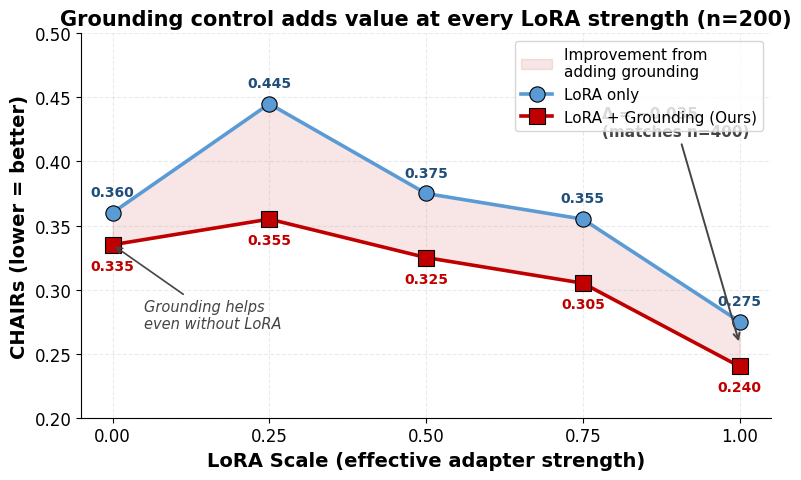

Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/fig_lora_scale_sweep.png
Saved: /content/drive/MyDrive/llava_hallucination_heads/poster_figures/fig_lora_scale_sweep.pdf


In [ ]:
import json, os
import matplotlib.pyplot as plt
import numpy as np

WORK_DIR = '/content/drive/MyDrive/llava_hallucination_heads'
FIG_DIR  = f'{WORK_DIR}/poster_figures'
os.makedirs(FIG_DIR, exist_ok=True)

with open(f'{WORK_DIR}/results/lora_scale_sweep_n200.json') as f:
    sweep = json.load(f)

scales = sorted(float(k) for k in sweep.keys())
lora_only       = [sweep[str(s)]['lora_only']['CHAIRs']      for s in scales]
lora_grounding  = [sweep[str(s)]['lora_grounding']['CHAIRs'] for s in scales]

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
})

fig, ax = plt.subplots(figsize=(8, 5))

# Shaded "improvement region" between the two lines
ax.fill_between(scales, lora_only, lora_grounding, color='#c00000', alpha=0.10,
                 label='Improvement from\nadding grounding')

# The two lines
ax.plot(scales, lora_only, 'o-', color='#5b9bd5', linewidth=2.6, markersize=11,
        label='LoRA only', markeredgecolor='black', markeredgewidth=0.8)
ax.plot(scales, lora_grounding, 's-', color='#c00000', linewidth=2.6, markersize=11,
        label='LoRA + Grounding (Ours)', markeredgecolor='black', markeredgewidth=0.8)

# Value labels
for s, v in zip(scales, lora_only):
    ax.annotate(f'{v:.3f}', (s, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10, color='#1f4e79',
                fontweight='bold')
for s, v in zip(scales, lora_grounding):
    ax.annotate(f'{v:.3f}', (s, v), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=10, color='#c00000',
                fontweight='bold')

# Annotation for the headline: gap at full LoRA matches n=400
ax.annotate('Δ = −0.035\n(matches n=400)',
            xy=(1.0, (lora_only[-1] + lora_grounding[-1])/2),
            xytext=(0.78, 0.42),
            fontsize=11, color='#444444', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.4))

# Annotation for the no-LoRA point
ax.annotate('Grounding helps\neven without LoRA',
            xy=(0.0, lora_grounding[0]), xytext=(0.05, 0.27),
            fontsize=10.5, color='#444444', style='italic',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.2))

ax.set_xlabel('LoRA Scale (effective adapter strength)', fontweight='bold')
ax.set_ylabel('CHAIRs (lower = better)', fontweight='bold')
ax.set_title('Grounding control adds value at every LoRA strength (n=200)',
              fontweight='bold')
ax.set_xticks(scales)
ax.set_xticklabels([f'{s:.2f}' for s in scales])
ax.set_ylim(0.20, 0.50)
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(loc='upper right', frameon=True, fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
out = f'{FIG_DIR}/fig_lora_scale_sweep.png'
plt.savefig(out)
plt.savefig(out.replace('.png', '.pdf'))
plt.show()
print(f'Saved: {out}')
print(f'Saved: {out.replace(".png", ".pdf")}')